In [1]:
from pathlib import Path
Path.cwd()

WindowsPath('D:/Yoobee/Term 3/Capstone/ai-dss-auckland-public-transport')

In [2]:
import pandas as pd
from pathlib import Path

# Correct project-relative path
GTFS_STATIC_PATH = Path("data/raw/gtfs_static")

# Load core GTFS Static files
routes = pd.read_csv(GTFS_STATIC_PATH / "routes.txt")
stops = pd.read_csv(GTFS_STATIC_PATH / "stops.txt")
trips = pd.read_csv(GTFS_STATIC_PATH / "trips.txt")
calendar = pd.read_csv(GTFS_STATIC_PATH / "calendar.txt")
calendar_dates = pd.read_csv(GTFS_STATIC_PATH / "calendar_dates.txt")

print("Routes:", routes.shape)
print("Stops:", stops.shape)
print("Trips:", trips.shape)
print("Calendar:", calendar.shape)
print("Calendar Dates:", calendar_dates.shape)

Routes: (220, 11)
Stops: (6471, 15)
Trips: (54512, 10)
Calendar: (121, 10)
Calendar Dates: (663, 3)


In [3]:
calendar_dates.columns.tolist()

['service_id', 'date', 'exception_type']

In [4]:
routes.columns.tolist()

['route_id',
 'agency_id',
 'route_short_name',
 'route_long_name',
 'route_desc',
 'route_type',
 'route_url',
 'route_color',
 'route_text_color',
 'route_sort_order',
 'contract_id']

In [5]:
# Display column names
print("Routes columns:")
print(routes.columns.tolist())

print("\nStops columns:")
print(stops.columns.tolist())

print("\nTrips columns:")
print(trips.columns.tolist())

Routes columns:
['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_desc', 'route_type', 'route_url', 'route_color', 'route_text_color', 'route_sort_order', 'contract_id']

Stops columns:
['stop_id', 'stop_code', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'zone_id', 'stop_url', 'location_type', 'parent_station', 'stop_timezone', 'platform_code', 'wheelchair_boarding', 'start_date', 'end_date']

Trips columns:
['route_id', 'service_id', 'trip_id', 'trip_headsign', 'trip_short_name', 'direction_id', 'block_id', 'shape_id', 'wheelchair_accessible', 'bikes_allowed']


In [6]:
# Preview sample records
display(routes.head())
display(stops.head())
display(trips.head())

,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type,route_url,route_color,route_text_color,route_sort_order,contract_id
0,101-202,NZB,101,101,NaN,3,NaN,NaN,NaN,NaN,19
1,STH-201,AM,STH,STH,NaN,2,NaN,D52923,FFFFFF,NaN,TRAIN
2,TIRI-240,EXPNZ,TIRI,TIRI,NaN,4,NaN,000000,FFFFFF,NaN,FERRY
3,TMK-202,NZB,TMK,TMK,NaN,3,NaN,007AB8,FFFFFF,NaN,16
4,WEST-201,AM,WEST,WEST,NaN,2,NaN,97C93D,152239,NaN,TRAIN


,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,stop_timezone,platform_code,wheelchair_boarding,start_date,end_date
0,1002-c8bb8209,1002,Stop A Lower Albert,NaN,-36.84316,174.76576,NaN,NaN,0,31986-b1e95b83,NaN,A,0,20260415,20260731
1,1003-ea94d2b2,1003,Stop B Lower Albert,NaN,-36.84381,174.76551,NaN,NaN,0,31986-b1e95b83,NaN,B,0,20260415,20260731
2,1004-42737000,1004,Stop C Lower Albert,NaN,-36.84403,174.76550,NaN,NaN,0,31986-b1e95b83,NaN,C,0,20260415,20260731
3,1005-c105552e,1005,Stop D Lower Albert,NaN,-36.84353,174.76571,NaN,NaN,0,31986-b1e95b83,NaN,D,0,20260415,20260731
4,1006-3a3acd71,1006,Stop E Lower Albert,NaN,-36.84290,174.76532,NaN,NaN,0,31986-b1e95b83,NaN,E,0,20260415,20260731


,route_id,service_id,trip_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible,bikes_allowed
0,147-203,Weekday-1,1001-14701-21000-2-2f648f34,Waitakere Township To Henderson,NaN,0,NaN,1001-14701-5b92fb16,0,0
1,147-203,Weekday-2,1001-14701-21000-2-6e698bd2,Waitakere Township To Henderson,NaN,0,NaN,1001-14701-5b92fb16,0,0
2,147-203,Weekend-1,1001-14701-21600-2-40fcfa30,Waitakere Township To Henderson,NaN,0,NaN,1001-14701-5b92fb16,0,0
3,147-203,Weekend-2,1001-14701-21600-2-8e6a272f,Waitakere Township To Henderson,NaN,0,NaN,1001-14701-5b92fb16,0,0
4,147-203,Weekday-2,1001-14701-22800-2-9cc956ca,Waitakere Township To Henderson,NaN,0,NaN,1001-14701-5b92fb16,0,0


In [11]:
#auckland route names for dashboard
routes[["route_id", "route_short_name", "route_long_name"]].head(10)

,route_id,route_short_name,route_long_name
0,101-202,101,101
1,STH-201,STH,STH
2,TIRI-240,TIRI,TIRI
3,TMK-202,TMK,TMK
4,WEST-201,WEST,WEST
5,WX1-207,WX1,WX1
6,105-202,105,105
7,MTIA-209,MTIA,MTIA
8,106-202,106,106
9,111-203,111,111


In [12]:
#data composition
#3 = bus, 2 = rail, 4 =  ferry
routes["route_type"].value_counts()

route_type
3    198
4     17
2      5
Name: count, dtype: int64

In [13]:
#confirms data have stop coordinates for mapping (geospatial info)
stops[["stop_id", "stop_name", "stop_lat", "stop_lon"]].head(10)

,stop_id,stop_name,stop_lat,stop_lon
0,1002-c8bb8209,Stop A Lower Albert,-36.84316,174.76576
1,1003-ea94d2b2,Stop B Lower Albert,-36.84381,174.76551
2,1004-42737000,Stop C Lower Albert,-36.84403,174.76550
3,1005-c105552e,Stop D Lower Albert,-36.84353,174.76571
4,1006-3a3acd71,Stop E Lower Albert,-36.84290,174.76532
5,1015-988bebe8,Water Street,-36.94186,174.85006
6,1018-1ed97058,Woolworths Quay Street,-36.84570,174.77520
7,1021-69759944,Portman Road/Penrose Road,-36.90884,174.82218
8,1022-f667c7a2,Rydal Drive,-36.90763,174.82445
9,1023-ca6f2b92,Cotswold Lane,-36.91158,174.82367


In [17]:
#check missing values
routes.isnull().sum()

route_id              0
agency_id             0
route_short_name      0
route_long_name       0
route_desc          220
route_type            0
route_url           220
route_color         188
route_text_color    188
route_sort_order    220
contract_id           0
dtype: int64

In [16]:
stops.isnull().sum()

stop_id                   0
stop_code                 0
stop_name                 0
stop_desc              6471
stop_lat                  0
stop_lon                  0
zone_id                6471
stop_url               6471
location_type             0
parent_station         6154
stop_timezone          6471
platform_code          6154
wheelchair_boarding       0
start_date                0
end_date                  0
dtype: int64

In [20]:
#Shows busiest routes (proxy via number of scheduled trips)
#top routes by trip count
top_routes = trips["route_id"].value_counts().head(10)
top_routes

route_id
NX1-203    1117
INN-202    1038
70-205     1008
NX2-207     880
18-202      874
OUT-202     817
WX1-207     786
75-202      753
30-202      747
TMK-202     717
Name: count, dtype: int64

In [28]:
#Join trips
trips_routes = trips.merge(routes, on="route_id", how="left")

trips_routes[["route_id", "route_short_name", "route_type"]].head()

,route_id,route_short_name,route_type
0,147-203,147,3
1,147-203,147,3
2,147-203,147,3
3,147-203,147,3
4,147-203,147,3


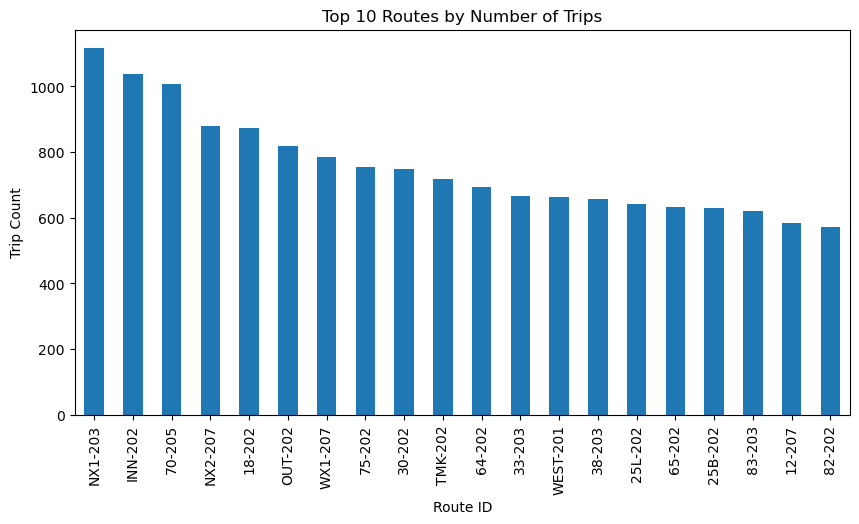

In [27]:
import matplotlib.pyplot as plt

top_routes.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Routes by Number of Trips")
plt.ylabel("Trip Count")
plt.xlabel("Route ID")
plt.show()

In [29]:
top_routes_named = trips_routes["route_short_name"].value_counts().head(10)
top_routes_named

route_short_name
NX1    1117
INN    1038
70     1008
NX2     880
18      874
OUT     817
WX1     786
75      753
30      747
TMK     717
Name: count, dtype: int64

<Axes: xlabel='route_short_name'>

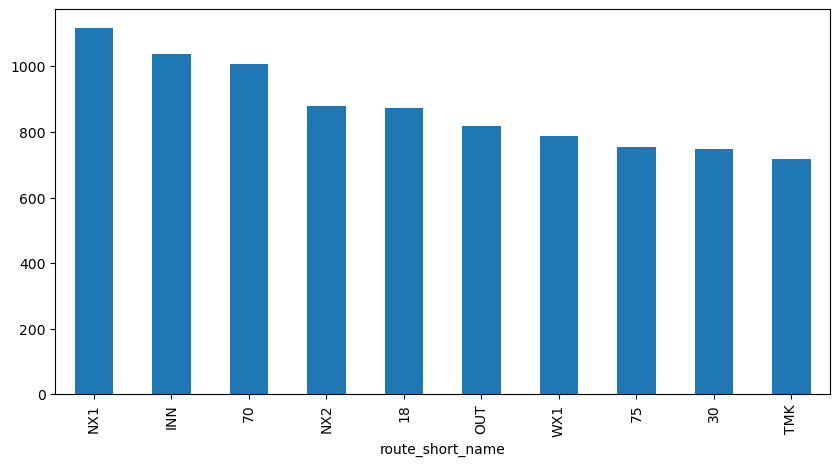

In [30]:
top_routes_named = trips_routes["route_short_name"].value_counts().head(10)

top_routes_named.plot(kind="bar", figsize=(10,5))